### Try to beat the Bayesian strategy

##### 1. Reproduce example from the lecture (electronic system production)

In [1]:
import numpy as np

class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

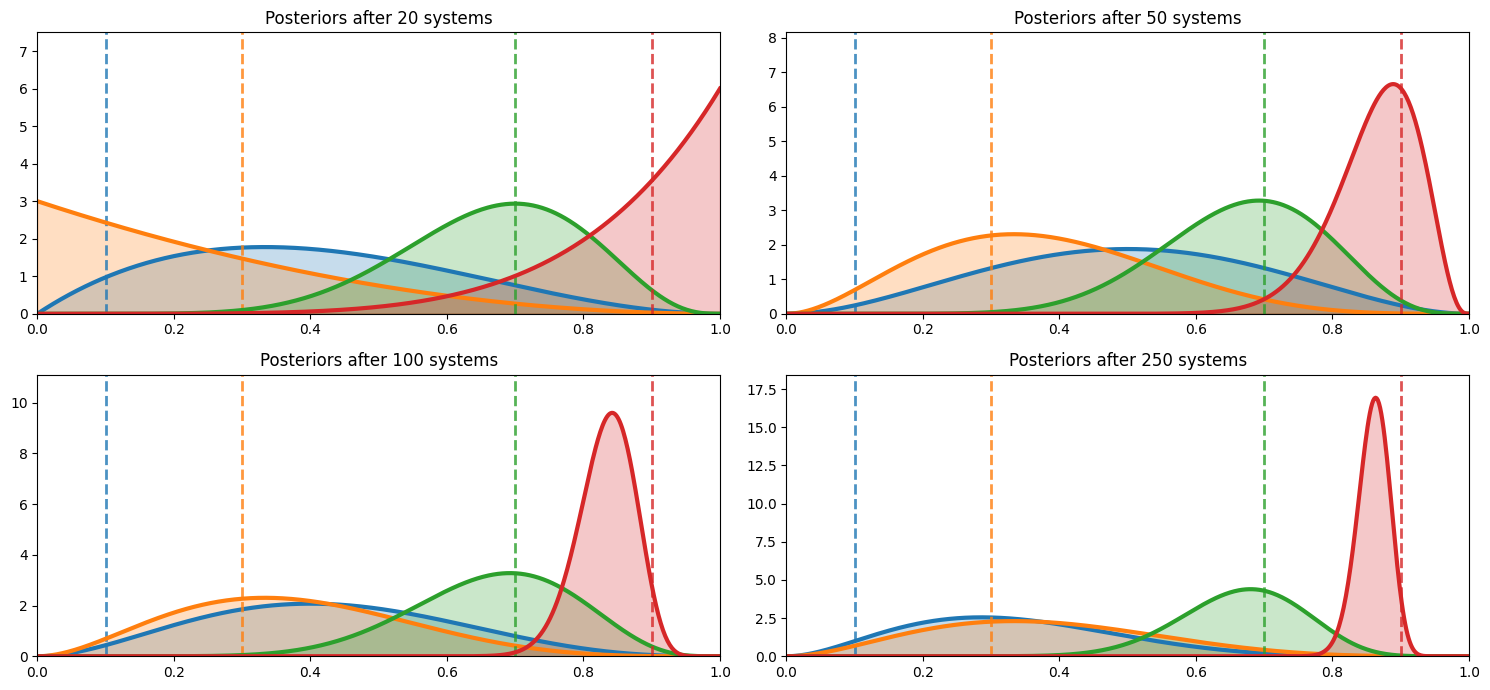

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import beta


qualities = [0.1, 0.3, 0.7, 0.9]
factory = Factory()
factory.set_batches(qualities)

checkpoints = [20, 50, 100, 250]
max_steps = max(checkpoints)

snapshots = {}

for step in range(1, max_steps + 1):
    factory.get_element()
    if step in checkpoints:
        snapshots[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]


x = np.linspace(0, 1, 600)
colors = ['C0', 'C1', 'C2', 'C3']
labels = [f'partia {i+1}' for i in range(len(qualities))]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
axes = axes.flatten()

for ax, step in zip(axes, checkpoints):
    ax.set_title(f'Posteriors after {step} systems')

    for i, (a, b_, q) in enumerate(snapshots[step]):
        y = beta.pdf(x, a, b_)
        ax.plot(x, y, color=colors[i], lw=3)
        ax.fill_between(x, y, color=colors[i], alpha=0.25)
        ax.axvline(q, color=colors[i], linestyle='--', lw=2, alpha=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(y) + 1.5)

plt.tight_layout()
plt.show()


##### 2. Implement last three strategies from slide 105 plus one of your own (other than the two remaining in the slide), compare results in a plot.

##### 3. In real life it is possible that the quality of components from a manufacture changes in time. Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the learned parameters of Beta distribution for each batch. Check using an appropriate example.

**Wnioski**